In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, random_split
from torch.cuda.amp import autocast, GradScaler
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
import os
import time
import copy


def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

# GPU Kontrolü
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Kullanılan Cihaz: {device}")
if torch.cuda.is_available():
    print(f"GPU Modeli: {torch.cuda.get_device_name(0)}")

Kullanılan Cihaz: cuda
GPU Modeli: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
def visualize_history(history, title="Model"):
    acc = history['train_acc']
    val_acc = history['val_acc']
    loss = history['train_loss']
    val_loss = history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title(f'{title} - Accuracy')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title(f'{title} - Loss')
    plt.grid(True)
    plt.show()

def evaluate_model_full(model, dataloader, class_names, title="Model"):
    model.eval()
    y_true = []
    y_pred = []
    y_probs = []
    
    print(f"{title} Değerlendiriliyor...")
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            
            # Olasılıklar
            probs = torch.nn.functional.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_probs.extend(probs[:, 1].cpu().numpy())
            
    # Rapor
    print(f"\n--- {title} DETAYLI RAPOR ---")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{title} Confusion Matrix')
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.title(f'{title} ROC Curve')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

def measure_speed(model, input_size, device, model_name="Model"):
    model.eval()
    # Modelin giriş boyutuna uygun dummy data (VGG:224, Inception:299)
    dummy_input = torch.randn(1, 3, input_size, input_size).to(device)
    
    # Isınma
    with torch.no_grad():
        for _ in range(5): _ = model(dummy_input)
            
    # Ölçüm
    start = time.time()
    with torch.no_grad():
        for _ in range(50): _ = model(dummy_input) # 50 tahmin
    end = time.time()
    
    avg_time = (end - start) / 50
    print(f"{model_name} Ortalama Tahmin Süresi: {avg_time*1000:.2f} ms")

=== MODEL 1: VGG-16 Hazırlanıyor ===


c:\ProgramData\anaconda3\envs\My_new_env\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/12
----------


c:\ProgramData\anaconda3\envs\My_new_env\lib\site-packages\PIL\Image.py:996: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


train Loss: 0.5424 Acc: 0.7164
val Loss: 0.4175 Acc: 0.8180

Epoch 2/12
----------
train Loss: 0.3424 Acc: 0.8552
val Loss: 0.3649 Acc: 0.8585

Epoch 3/12
----------
train Loss: 0.2511 Acc: 0.9005
val Loss: 0.3517 Acc: 0.8603

Epoch 4/12
----------
train Loss: 0.1811 Acc: 0.9308
val Loss: 0.3483 Acc: 0.8658

Epoch 5/12
----------
train Loss: 0.1161 Acc: 0.9555
val Loss: 0.4675 Acc: 0.8732

Epoch 6/12
----------
train Loss: 0.0930 Acc: 0.9677
val Loss: 0.4189 Acc: 0.8824

Epoch 7/12
----------
train Loss: 0.0581 Acc: 0.9811
val Loss: 0.4128 Acc: 0.8768

Epoch 8/12
----------
train Loss: 0.0630 Acc: 0.9795
val Loss: 0.4149 Acc: 0.8842

Epoch 9/12
----------
train Loss: 0.0352 Acc: 0.9910
val Loss: 0.4205 Acc: 0.8842

Epoch 10/12
----------
train Loss: 0.0282 Acc: 0.9925
val Loss: 0.4181 Acc: 0.8879

Epoch 11/12
----------
train Loss: 0.0241 Acc: 0.9913
val Loss: 0.4401 Acc: 0.8842

Epoch 12/12
----------
train Loss: 0.0206 Acc: 0.9933
val Loss: 0.4437 Acc: 0.8860



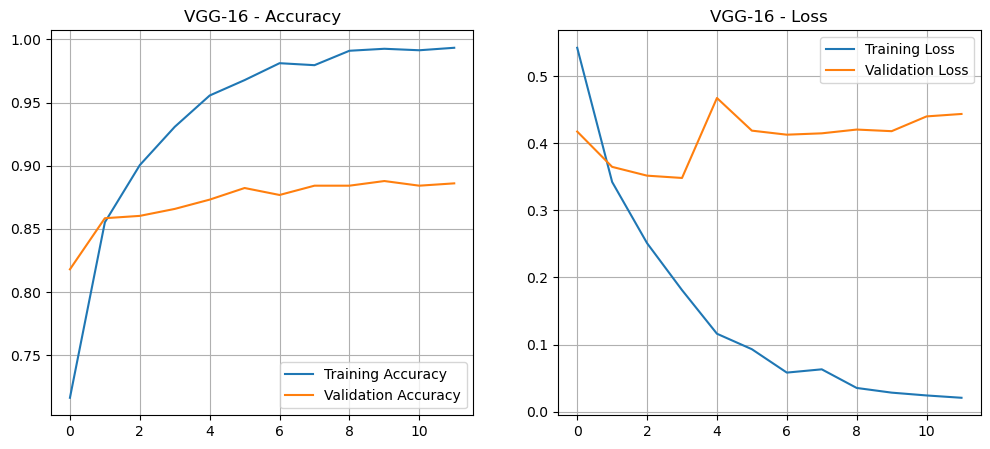

VGG-16 Değerlendiriliyor...

--- VGG-16 DETAYLI RAPOR ---
              precision    recall  f1-score   support

       Kirli       0.88      0.93      0.90       255
       Temiz       0.93      0.89      0.91       291

    accuracy                           0.91       546
   macro avg       0.91      0.91      0.91       546
weighted avg       0.91      0.91      0.91       546



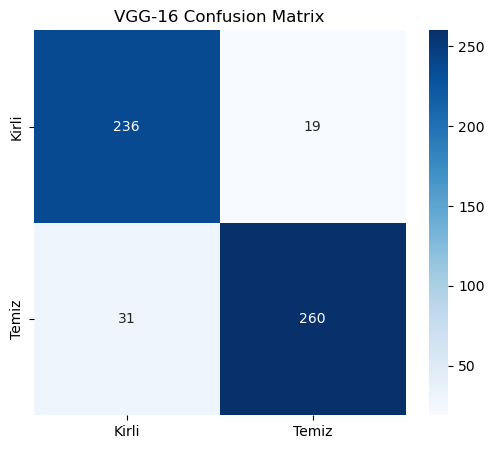

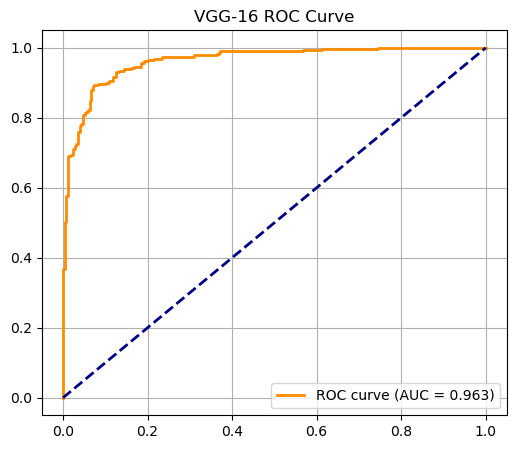

VGG-16 Ortalama Tahmin Süresi: 4.49 ms


In [3]:
# --- AYARLAR ---
data_dir = "panel_data" 
BATCH_SIZE = 64
NUM_WORKERS = 0 
# ---------------

print("=== MODEL 1: VGG-16 Hazırlanıyor ===")

# 1. Veri Hazırlığı (224x224)
data_transforms_vgg = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2), # Gelişmiş Augmentation
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

full_dataset = datasets.ImageFolder(data_dir, transform=data_transforms_vgg['train'])
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])


val_dataset.dataset.transform = data_transforms_vgg['val']
test_dataset.dataset.transform = data_transforms_vgg['val']

dataloaders_vgg = {
    'train': DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True
    ),
    'val': DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True
    ),
    'test': DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )
}

class_names = full_dataset.classes

# 2. Model Kurulumu (VGG-16)
model_vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

# VGG'nin son katmanı 'classifier' dizisinin 6. elemanıdır
num_ftrs = model_vgg.classifier[6].in_features
model_vgg.classifier[6] = nn.Linear(num_ftrs, 2) # 2 Sınıf: Clean/Dirty

model_vgg = model_vgg.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_vgg = optim.SGD(model_vgg.parameters(), lr=0.001, momentum=0.9) # VGG genelde SGD sever
exp_lr_scheduler = lr_scheduler.ReduceLROnPlateau(optimizer_vgg, mode='min', factor=0.1, patience=3, verbose=True)

# 3. Standart Eğitim Fonksiyonu
def train_standard_model(model, loaders, criterion, optimizer, scheduler, num_epochs=10):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train': model.train()
            else: model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in loaders[phase]:
                inputs = inputs.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(loaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(loaders[phase].dataset)
            
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'val':
                scheduler.step(epoch_loss)
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
        print()

    model.load_state_dict(best_model_wts)
    return model, history

# 4. Eğitimi Başlatma (VGG-16)
model_vgg, history_vgg = train_standard_model(
    model_vgg, dataloaders_vgg, criterion, optimizer_vgg, exp_lr_scheduler, num_epochs=12
)

# 5. Sonuçlar
visualize_history(history_vgg, title="VGG-16")
evaluate_model_full(model_vgg, dataloaders_vgg['test'], class_names, title="VGG-16")
measure_speed(model_vgg, 224, device, "VGG-16")
torch.save(model_vgg.state_dict(), 'PATtechs_VGG16_Final.pth')

=== MODEL 2: Inception v3 Hazırlanıyor ===


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to C:\Users\Rabotyaga/.cache\torch\hub\checkpoints\inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [01:29<00:00, 1.22MB/s] 


Epoch 1/12
----------


c:\ProgramData\anaconda3\envs\My_new_env\lib\site-packages\PIL\Image.py:996: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


train Loss: 0.7432 Acc: 0.7573
val Loss: 0.4752 Acc: 0.8254

Epoch 2/12
----------
train Loss: 0.5801 Acc: 0.8131
val Loss: 0.4158 Acc: 0.8217

Epoch 3/12
----------
train Loss: 0.4900 Acc: 0.8462
val Loss: 0.4340 Acc: 0.8254

Epoch 4/12
----------
train Loss: 0.4882 Acc: 0.8564
val Loss: 0.5906 Acc: 0.8382

Epoch 5/12
----------
train Loss: 0.4593 Acc: 0.8666
val Loss: 0.3856 Acc: 0.8585

Epoch 6/12
----------
train Loss: 0.3857 Acc: 0.8954
val Loss: 0.3406 Acc: 0.8732

Epoch 7/12
----------
train Loss: 0.3334 Acc: 0.9127
val Loss: 0.4717 Acc: 0.8474

Epoch 8/12
----------
train Loss: 0.3269 Acc: 0.9135
val Loss: 0.5367 Acc: 0.8346

Epoch 9/12
----------
train Loss: 0.2712 Acc: 0.9296
val Loss: 0.4599 Acc: 0.8805

Epoch 10/12
----------
train Loss: 0.2505 Acc: 0.9351
val Loss: 0.3970 Acc: 0.8676

Epoch 11/12
----------
train Loss: 0.1299 Acc: 0.9709
val Loss: 0.3170 Acc: 0.9007

Epoch 12/12
----------
train Loss: 0.0735 Acc: 0.9862
val Loss: 0.3602 Acc: 0.9044



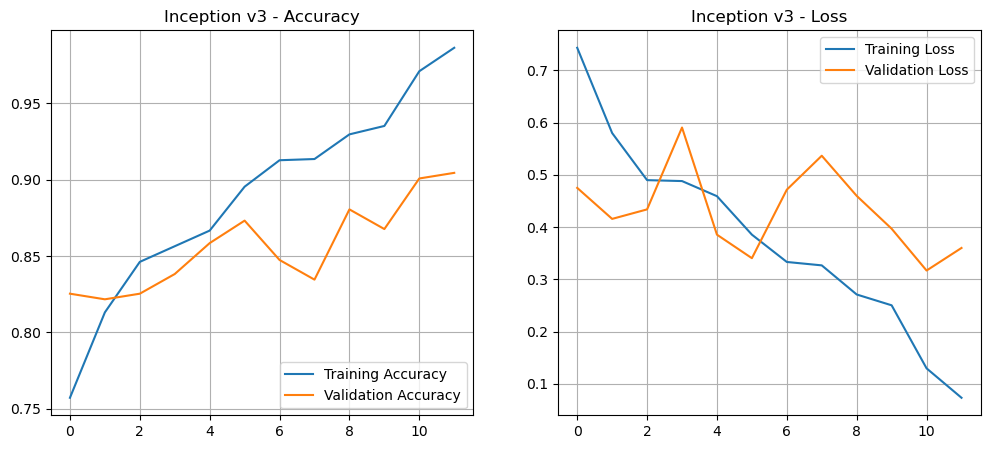

Inception v3 Değerlendiriliyor...

--- Inception v3 DETAYLI RAPOR ---
              precision    recall  f1-score   support

       Kirli       0.91      0.90      0.90       270
       Temiz       0.90      0.91      0.90       276

    accuracy                           0.90       546
   macro avg       0.90      0.90      0.90       546
weighted avg       0.90      0.90      0.90       546



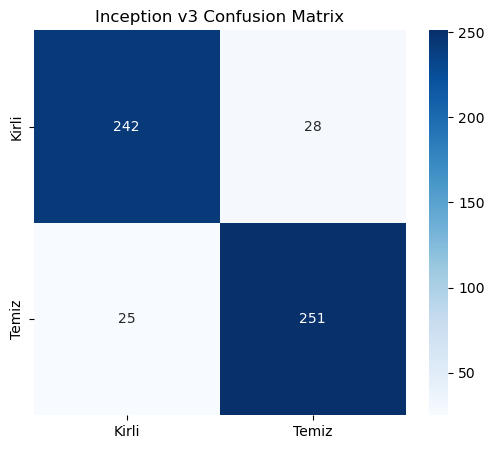

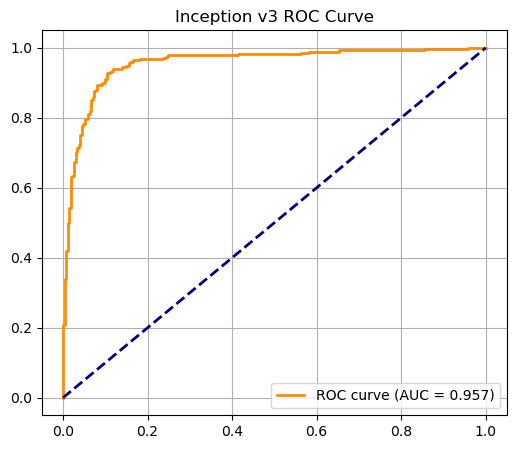

Inception v3 Ortalama Tahmin Süresi: 7.62 ms


In [4]:
print("=== MODEL 2: Inception v3 Hazırlanıyor ===")

# 1. Veri Hazırlığı (299x299 - Inception İçin Zorunlu)
data_transforms_inc = {
    'train': transforms.Compose([
        transforms.Resize((299, 299)), # KRİTİK NOKTA
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]) # Inception için bu norm önerilir
    ]),
    'val': transforms.Compose([
        transforms.Resize((299, 299)),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ]),
}

# Dataset'i yeniden oluşturuyoruz (Transform değiştiği için)
full_dataset_inc = datasets.ImageFolder(data_dir, transform=data_transforms_inc['train'])
train_ds_inc, val_ds_inc, test_ds_inc = random_split(full_dataset_inc, [train_size, val_size, test_size])

val_ds_inc.dataset.transform = data_transforms_inc['val']
test_ds_inc.dataset.transform = data_transforms_inc['val']

dataloaders_inc = {
    'train': DataLoader(train_ds_inc, batch_size=32, shuffle=True, num_workers=NUM_WORKERS),
    'val': DataLoader(val_ds_inc, batch_size=32, shuffle=False, num_workers=NUM_WORKERS),
    'test': DataLoader(test_ds_inc, batch_size=32, shuffle=False, num_workers=NUM_WORKERS)
}

# 2. Model Kurulumu (Inception v3)
model_inc = models.inception_v3(weights=models.Inception_V3_Weights.DEFAULT)

num_ftrs = model_inc.fc.in_features
model_inc.fc = nn.Linear(num_ftrs, 2)

num_ftrs_aux = model_inc.AuxLogits.fc.in_features
model_inc.AuxLogits.fc = nn.Linear(num_ftrs_aux, 2)

model_inc = model_inc.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_inc = optim.Adam(model_inc.parameters(), lr=0.001)
exp_lr_scheduler_inc = lr_scheduler.ReduceLROnPlateau(optimizer_inc, mode='min', factor=0.1, patience=3)

# 3. Inception Özel Eğitim Fonksiyonu (Aux Logits Handle Eden)
def train_inception_model(model, loaders, criterion, optimizer, scheduler, num_epochs=10):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train': model.train()
            else: model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in loaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    if phase == 'train':
                        # Inception eğitimde (output, aux_output) döner
                        outputs, aux_outputs = model(inputs)
                        loss1 = criterion(outputs, labels)
                        loss2 = criterion(aux_outputs, labels)
                        loss = loss1 + 0.4 * loss2 
                    else:
                        outputs = model(inputs)
                        loss = criterion(outputs, labels)

                    _, preds = torch.max(outputs, 1)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(loaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(loaders[phase].dataset)
            
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'val':
                scheduler.step(epoch_loss)
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
        print()

    model.load_state_dict(best_model_wts)
    return model, history

# 4. Eğitimi Başlatma
model_inc, history_inc = train_inception_model(
    model_inc, dataloaders_inc, criterion, optimizer_inc, exp_lr_scheduler_inc, num_epochs=12
)

# 5. Sonuçlar
visualize_history(history_inc, title="Inception v3")
evaluate_model_full(model_inc, dataloaders_inc['test'], class_names, title="Inception v3")
measure_speed(model_inc, 299, device, "Inception v3") # Giriş 299 olmalı
torch.save(model_inc.state_dict(), 'PATtechs_InceptionV3_Final.pth')

Isı Haritaları (Heatmaps) Çiziliyor...


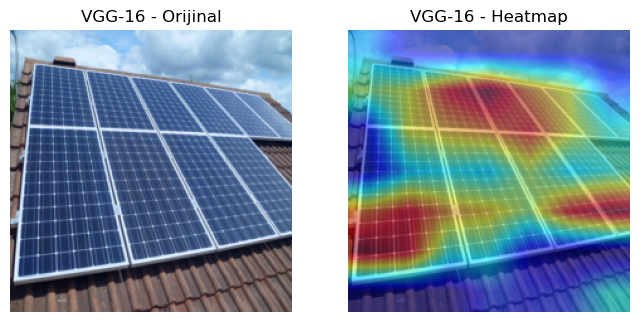

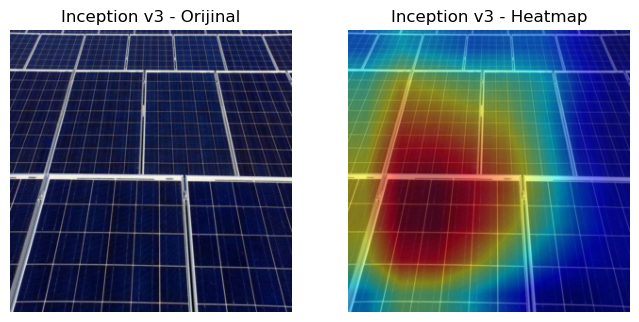

In [5]:
# Grad-CAM 
try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
except ImportError:
    import sys
    !{sys.executable} -m pip install grad-cam
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

def show_gradcam(model, target_layer, dataset, input_size, title="Grad-CAM"):
    model.eval()
    # Rastgele bir Kirli (Class 1) resim bul
    idx = 0
    while True:
        img, label = dataset[idx]
        if label == 1: break # Kirli bulana kadar ara
        idx += 1
        
    input_tensor = img.unsqueeze(0).to(device)
    
    # Görselleştirme için normalize işlemini geri al (Kabaca)
    rgb_img = img.permute(1, 2, 0).numpy()
    rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())

    cam = GradCAM(model=model, target_layers=[target_layer])
    targets = [ClassifierOutputTarget(1)]

    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0, :]
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
    
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(rgb_img)
    plt.title(f"{title} - Orijinal")
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(visualization)
    plt.title(f"{title} - Heatmap")
    plt.axis('off')
    plt.show()

print("Isı Haritaları (Heatmaps) Çiziliyor...")

# VGG-16 için Hedef: Son konvolüsyon katmanı (features[-1])
show_gradcam(model_vgg, model_vgg.features[-1], test_dataset, 224, "VGG-16")

# Inception v3 için Hedef: Mixed_7c katmanı
show_gradcam(model_inc, model_inc.Mixed_7c, test_ds_inc, 299, "Inception v3")